# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

In [230]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [231]:

#import the DataSet from de csv file 
df = pd.read_csv("/Users/felipemartignon/IRONHACK/IA_Eng/2nd_week/labs_2nd_week/lab-ml-and-linear-regression/data/housing.csv")

# 1st inspection 
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [232]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [233]:
# with this code we wil find out what shape does our data set has 
print("Dataset shape:", df.shape)

Dataset shape: (20640, 10)


In [234]:
# we continue reviewing the data to find out the numerical values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [235]:
# Check for missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [236]:
# looking at a quick statistical overview of every column: count, mean, standard deviation, min/max, and quartiles.
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

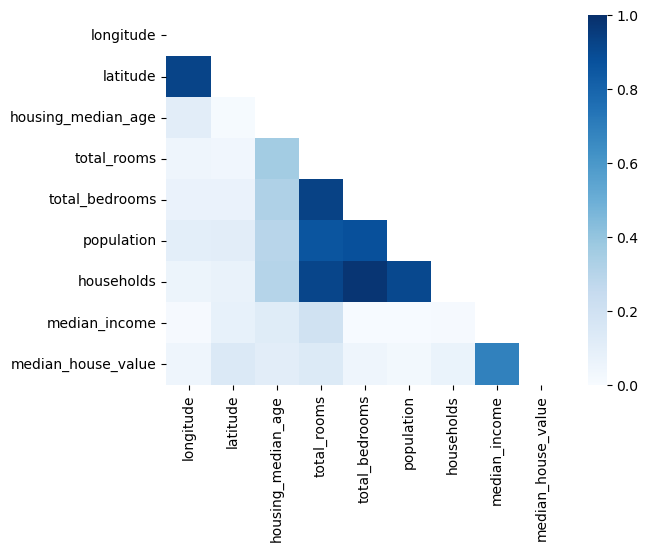

In [237]:

mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool)) 

sns.heatmap(
    df.corr(numeric_only=True).abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
    mask=mask
)

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [238]:
# here we look for the NaN values 
df.isnull().sum().sort_values(ascending=False)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [239]:
# we will fill with the average 

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [240]:
# we verify the droping by looking for the NaN values again
df.isnull().sum().sort_values(ascending=False)

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [241]:
df.head(12)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [242]:
# we create the 3 new columns 
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms'] 
df['rooms_per_household'] = df['total_rooms'] / df['households']

# we verify
df.head(12)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,population_per_household,bedrooms_per_room,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2.555556,0.146591,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2.109842,0.155797,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2.802260,0.129516,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2.547945,0.184458,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2.181467,0.172096,6.281853
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,2.139896,0.231774,4.761658
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,2.128405,0.192899,4.931907
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,1.788253,0.221327,4.797527
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,2.026891,0.260274,4.294118
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,2.172269,0.199211,4.970588


3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [243]:
#
# summarize the numeric columns

df[['rooms_per_household']].describe()

,rooms_per_household
count,20640.000000
mean,5.429000
std,2.474173
min,0.846154
25%,4.440716
50%,5.229129
75%,6.052381
max,141.909091


findings:
+ we see that the minimun is below 1 and is not likely to see a house with less than a room
+ we also see the max is 141.90 way to high 

In [244]:
# we sort in asending and take a look at the head 
df[['rooms_per_household']].sort_values(by='rooms_per_household', ascending=True).head(5)



,rooms_per_household
5916,0.846154
8219,0.888889
3126,1.000000
14818,1.130435
17820,1.130435


In [245]:
# we take a look at the tail 
df[['rooms_per_household']].sort_values(by='rooms_per_household', ascending=True).tail(5)

,rooms_per_household
11862,59.875000
1913,61.812500
12447,62.422222
1979,132.533333
1914,141.909091


In [246]:
# we eliminate the 4 index 
df = df.drop(index=[5916])  
df = df.drop(index=[8219])
df = df.drop(index=[1979])
df = df.drop(index=[1914])

In [247]:
# we verify the extremes from the DataFrame 

df[['rooms_per_household']].describe()

,rooms_per_household
count,20636.000000
mean,5.416669
std,2.105933
min,1.000000
25%,4.440869
50%,5.229129
75%,6.052195
max,62.422222


# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


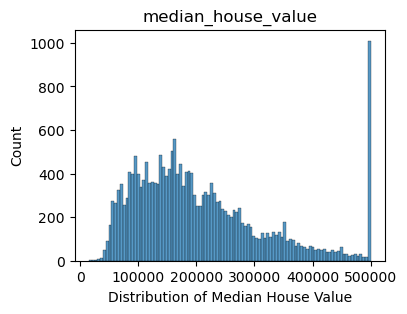

In [248]:
# render a histogram with the median_house_value

plt.figure(figsize=(4, 3))
sns.histplot(df['median_house_value'], bins=100, kde=False)
plt.xlabel('Distribution of Median House Value')
plt.ylabel('Count')
plt.title('median_house_value')
plt.show()

We see a notoriusly big number of houses at a very high median house Value probably all the data fartehr than this point was store togetehr 

2. Check out what variables correlates the most with "median house value"

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

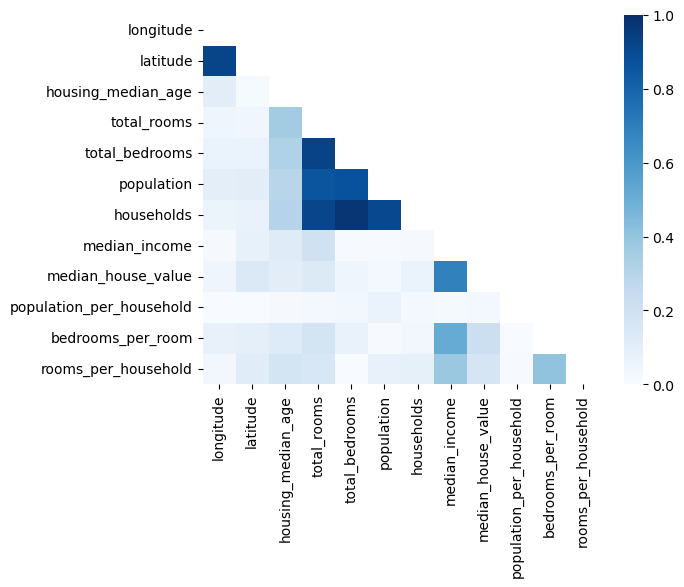

In [249]:
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool)) 

sns.heatmap(
    df.corr(numeric_only=True).abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
    mask=mask
)

median_house_value has a high correlation with median income 

3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


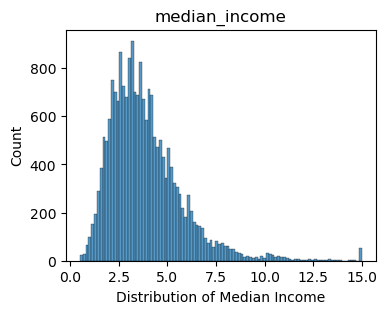

In [250]:
# render a histogram with the median_income

plt.figure(figsize=(4, 3))
sns.histplot(df['median_income'], bins=100, kde=False)
plt.xlabel('Distribution of Median Income')
plt.ylabel('Count')
plt.title('median_income')
plt.show()

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


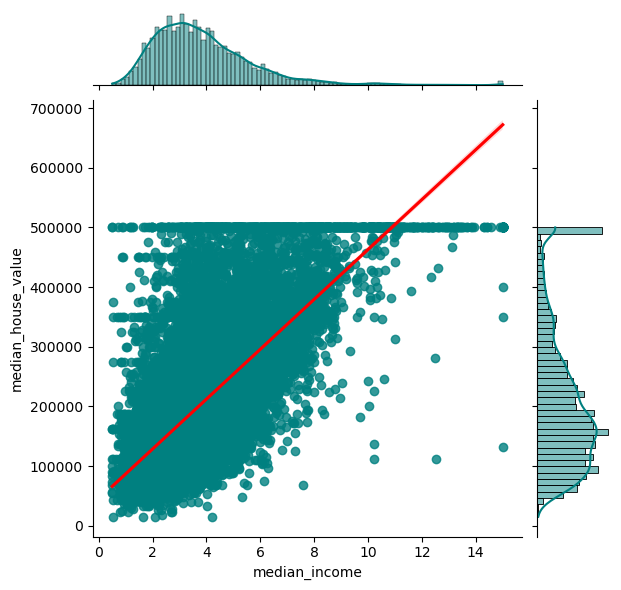

In [251]:
# 
sns.jointplot(
    x='median_income', 
    y='median_house_value', 
    data=df, 
    kind="reg", 
    color="teal", 
    joint_kws={'line_kws':{'color':'red'}}
)

plt.show()

We see the correlation between median income and median house value 

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

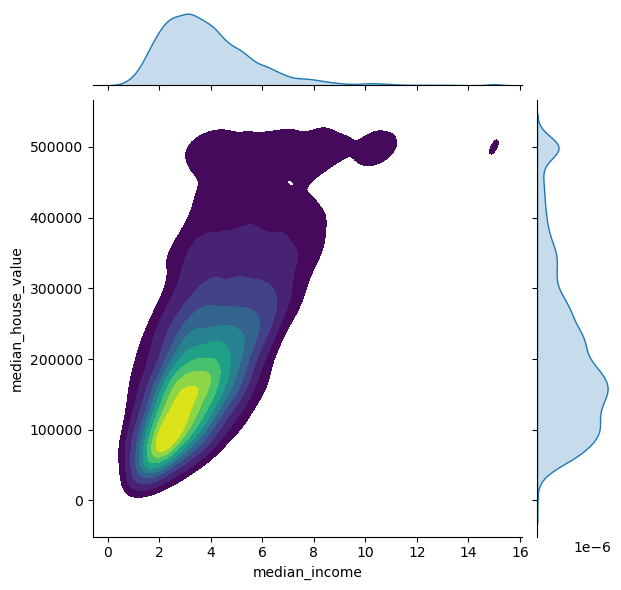

In [252]:
# the same graph clanging the type to "kde"
sns.jointplot(
    x='median_income', 
    y='median_house_value', 
    data=df, 
    kind="kde", 
    cmap="viridis", 
    fill=True
)

plt.show()

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [253]:
# creating new columns 

df['income_cat'] = pd.qcut(df['median_income'], q=[0, 0.25, 0.5, 0.75, 0.95, 1], labels=["Low", "Below_Average", "Above_Average", "High", "Very High"])

In [254]:
# we check if it worked 

df['income_cat'].value_counts()

income_cat
Above_Average    5160
Low              5159
Below_Average    5159
High             4126
Very High        1032
Name: count, dtype: int64

2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


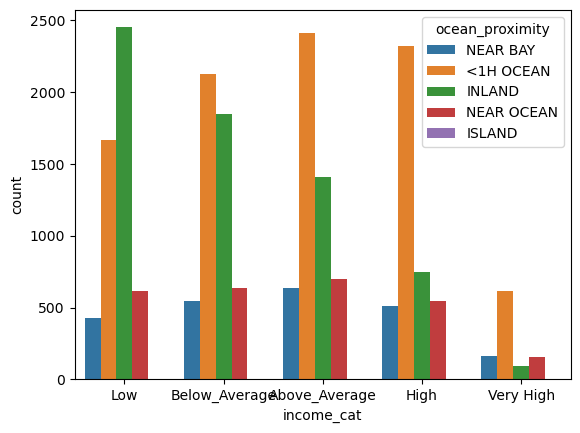

In [255]:

# Creamos el gráfico de barras cruzando los ingresos con la cercanía al mar
sns.countplot(x='income_cat', hue='ocean_proximity', data=df)

# Mostramos el gráfico
plt.show()

in all the categories we see that the once that are near the ocean are highm and in the low income we see that inland is beiger 

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

/Users/felipemartignon/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


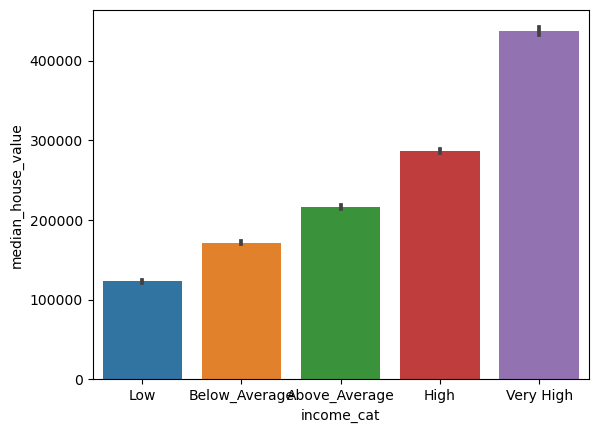

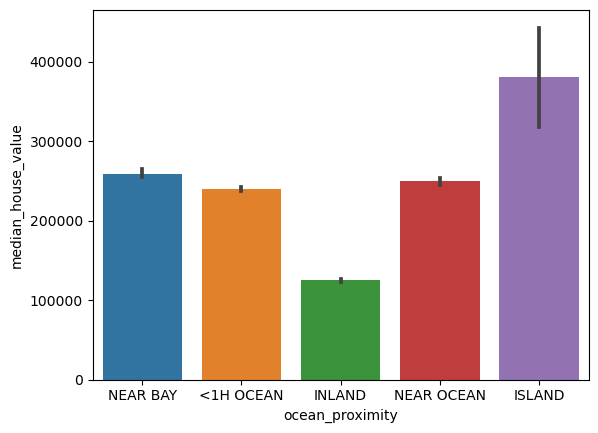

In [256]:
# Gráfico 1: Relación entre Categoría de Ingresos y el Valor de la Casa
sns.barplot(x='income_cat', y='median_house_value', data=df)
plt.show()

# Gráfico 2: Relación entre Cercanía al Océano y el Valor de la Casa
sns.barplot(x='ocean_proximity', y='median_house_value', data=df)
plt.show()

the 1st graph shows that even that the very high income category is samall has a higher median house value
the 3nd graph coroborates that inland houses are cheaper we saw before with a great number of low  income 

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [257]:
# 1. we create the pivotal data frame 
df_pivot = pd.crosstab(index=df['income_cat'], columns=df['ocean_proximity'])

# 2.drop island 
df_pivot = df_pivot.drop(columns=['ISLAND'])

# 3. show the dataframe 
df_pivot

ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,1669,2449,426,614
Below_Average,2124,1847,548,636
Above_Average,2412,1409,638,701
High,2318,748,513,547
Very High,612,96,165,159


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

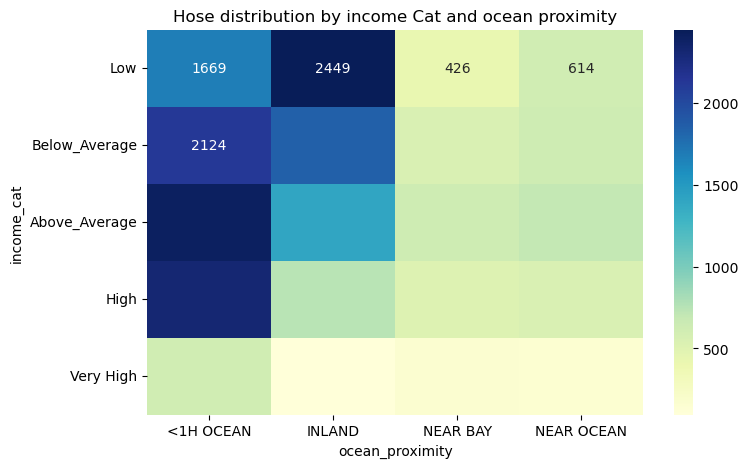

In [258]:
# graph size 
plt.figure(figsize=(8, 5))

# create heat map 
sns.heatmap(df_pivot, annot=True, fmt='d', cmap='YlGnBu')

# add lables 
plt.title('Hose distribution by income Cat and ocean proximity')
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [259]:
# drop the column "income_cat"
df = df.drop(columns=["income_cat"])

In [260]:
# we verify 
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,population_per_household,bedrooms_per_room,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2.555556,0.146591,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2.109842,0.155797,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2.802260,0.129516,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2.547945,0.184458,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2.181467,0.172096,6.281853


2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [261]:
import scipy.stats as stats

In [262]:
z_scored = df.select_dtypes(include= ['float64']).apply(lambda x : stats.zscore(x))

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [263]:
# here we get thte dummies 
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [264]:
# we check 
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,population_per_household,bedrooms_per_room,rooms_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,2.555556,0.146591,6.984127,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,2.109842,0.155797,6.238137,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,2.802260,0.129516,8.288136,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,2.547945,0.184458,5.817352,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,2.181467,0.172096,6.281853,False,False,True,False


4. Save our predicting variable to `y`.

In [265]:
from sklearn.model_selection import train_test_split

y = df['median_house_value']

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [266]:
# we concatenate z_scored drop median_house_value 
X = pd.concat([z_scored, df], axis=1).drop(columns=['median_house_value'], errors='ignore')

# verifiy
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,population_per_household,bedrooms_per_room,...,population,households,median_income,population_per_household,bedrooms_per_room,rooms_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327701,1.052665,0.982224,-0.804958,-0.975370,-0.974710,-0.977332,2.344595,-0.049604,-0.975835,...,322.0,126.0,8.3252,2.555556,0.146591,6.984127,False,False,True,False
1,-1.322710,1.043301,-0.606873,2.045696,1.354918,0.861243,1.669812,2.332068,-0.092516,-0.843401,...,2401.0,1138.0,8.3014,2.109842,0.155797,6.238137,False,False,True,False
2,-1.332692,1.038619,1.856227,-0.535890,-0.829876,-0.821052,-0.843928,1.782561,-0.025852,-1.221476,...,496.0,177.0,7.2574,2.802260,0.129516,8.288136,False,False,True,False
3,-1.337683,1.038619,1.856227,-0.624357,-0.722544,-0.766300,-0.734067,0.932876,-0.050337,-0.431069,...,558.0,219.0,5.6431,2.547945,0.184458,5.817352,False,False,True,False
4,-1.337683,1.038619,1.856227,-0.462549,-0.615213,-0.760118,-0.629436,-0.012919,-0.085620,-0.608917,...,565.0,259.0,3.8462,2.181467,0.172096,6.281853,False,False,True,False


# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [267]:
# first split: train (80%) and temporary set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [268]:
from sklearn.linear_model import LinearRegression

# 1. Create the model
model = LinearRegression()



In [269]:
# 2. Train on the training set
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

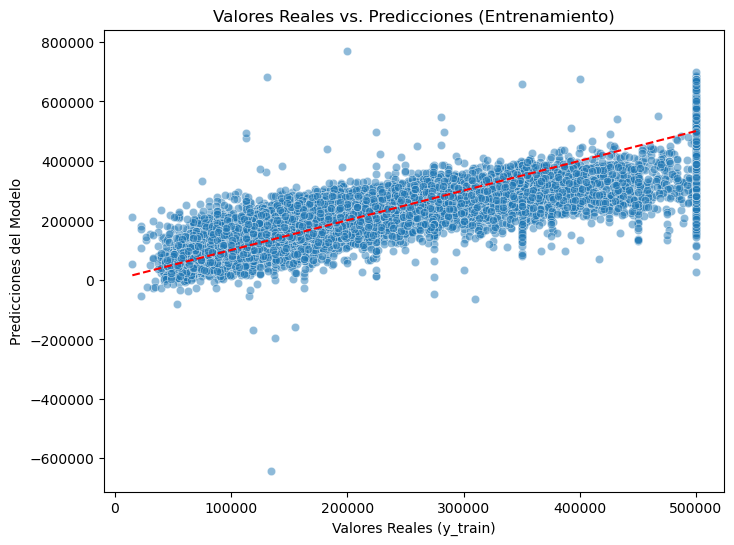

In [270]:
# 1. Calculamos las predicciones para el set de entrenamiento
y_train_pred = model.predict(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.5)

# Añadimos etiquetas para que quede profesional
plt.xlabel('Valores Reales (y_train)')
plt.ylabel('Predicciones del Modelo')
plt.title('Valores Reales vs. Predicciones (Entrenamiento)')

# Dibujamos la línea de referencia ideal (diagonal)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--')

plt.show()

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [271]:
from sklearn import metrics

In [277]:
from sklearn.metrics import mean_squared_error, r2_score

# predictions 
y_train_pred = model.predict(X_train)


#  metrics  Train
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)



# show results
print("--- MÉTRICAS DE ENTRENAMIENTO ---")
print(f"MSE: {mse_train:.2f}")
print(f"R² Score: {r2_train:.4f}\n")


--- MÉTRICAS DE ENTRENAMIENTO ---
MSE: 4697957220.13
R² Score: 0.6486



#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

In [ ]:
# predictios
y_test_pred = model.predict(X_test)






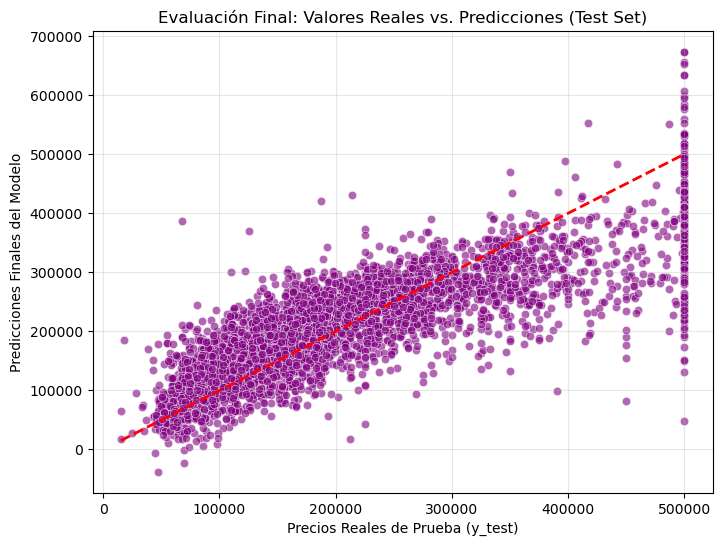

In [279]:




plt.figure(figsize=(8, 6))

# 3. Dibujamos el Scatterplot con los datos de prueba
sns.scatterplot(x=y_test, y=y_test_pred, color='purple', alpha=0.6)

# Dibujamos la línea de predicción perfecta (identidad)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

# Personalizamos los títulos para que el laboratorio quede profesional
plt.xlabel('Precios Reales de Prueba (y_test)')
plt.ylabel('Predicciones Finales del Modelo')
plt.title('Evaluación Final: Valores Reales vs. Predicciones (Test Set)')
plt.grid(True, alpha=0.3)

plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [ ]:
# metrics (Test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred) 

In [ ]:
# show result 
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

In [ ]:
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)


print(f"RMSE en el set de Entrenamiento: ${rmse_train:,.2f}")
print(f"RMSE en el set de Prueba (Test): ${rmse_test:,.2f}")

--- ROOT MEAN SQUARED ERROR (RMSE) ---
RMSE en el set de Entrenamiento: $68,541.65
RMSE en el set de Prueba (Test): $67,602.06


# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [273]:
from sklearn.ensemble import RandomForestRegressor

2. Make prediction on the test data and evaluate you results.